# Overview

This notebook builds a regression pipeline to predict actual hospital length of stay using the Diabetes 130-US Hospitals dataset. It focuses on a practical first-pass model built from cleaner structured features and compares several regression baselines before selecting the best model by mean absolute error.

# Load data

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

try:
    notebook_dir = Path(__file__).resolve().parent
except NameError:
    notebook_dir = Path.cwd()

candidate_roots = [
    notebook_dir,
    notebook_dir.parent,
]

repo_root = None
for candidate in candidate_roots:
    data_path_candidate = candidate / 'data' / 'raw' / 'diabetic_data.csv'
    if data_path_candidate.exists():
        repo_root = candidate
        break

if repo_root is None:
    repo_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir

DATA_PATH = repo_root / 'data' / 'raw' / 'diabetic_data.csv'

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Could not find diabetic_data.csv at {DATA_PATH}. Place the file in data/raw/.'
    )

df = pd.read_csv(DATA_PATH).replace('?', np.nan)
print(f'Data path: {DATA_PATH}')
print(f'Dataset shape: {df.shape}')
display(df.head())


Data path: /Users/ahannair/Desktop/LengthOfStayPredictionPipeline/data/raw/diabetic_data.csv
Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Target definition

The regression target is `time_in_hospital`, which represents the observed number of days a patient stayed in the hospital during the recorded encounter.

In [2]:
target_column = 'time_in_hospital'
if target_column not in df.columns:
    raise KeyError("Column 'time_in_hospital' is required for this notebook.")

target_preview = pd.to_numeric(df[target_column], errors='coerce')
print(target_preview.describe())


count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64


# Data cleaning

For inspection and modeling, placeholder values of `?` are treated as missing. Rows with missing or invalid target values are removed so the regression target remains well-defined.

In [3]:
df_clean = df.copy()
df_clean[target_column] = pd.to_numeric(df_clean[target_column], errors='coerce')
df_clean = df_clean.loc[df_clean[target_column].notna()].copy()
df_clean[target_column] = df_clean[target_column].astype(float)

missing_summary = (
    df_clean.isna()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: (x['missing_count'] / len(df_clean) * 100).round(2))
    .sort_values(['missing_count', 'missing_pct'], ascending=False)
)

print(f'Rows after target cleaning: {len(df_clean):,}')
display(missing_summary.head(15))


Rows after target cleaning: 101,766


,missing_count,missing_pct
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
encounter_id,0,0.00


# Feature selection

This first version of the regression pipeline uses cleaner structured demographic, admission, discharge, and utilization features. Messier diagnosis-code fields are intentionally left out of the production-style feature set for now.

In [4]:
candidate_categorical_features = [
    'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed'
]
candidate_numeric_features = [
    'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient'
]

categorical_features = [col for col in candidate_categorical_features if col in df_clean.columns]
numeric_features = [col for col in candidate_numeric_features if col in df_clean.columns]
selected_features = numeric_features + categorical_features

if not selected_features:
    raise ValueError('None of the configured candidate features are present in the dataset.')

feature_summary = pd.DataFrame({
    'feature': selected_features,
    'feature_type': ['numeric'] * len(numeric_features) + ['categorical'] * len(categorical_features),
})

display(feature_summary)
print(f'Selected {len(selected_features)} features.')


,feature,feature_type
0,num_lab_procedures,numeric
1,num_procedures,numeric
2,num_medications,numeric
3,number_outpatient,numeric
4,number_emergency,numeric
5,number_inpatient,numeric
6,race,categorical
7,gender,categorical
8,age,categorical
9,admission_type_id,categorical


Selected 17 features.


# Train/test split

In [5]:
X = df_clean[selected_features].copy()
y = df_clean[target_column].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')


X_train shape: (81412, 17)
X_test shape: (20354, 17)
y_train shape: (81412,)
y_test shape: (20354,)


# Preprocessing pipeline

In [6]:
def build_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


transformers = []

if numeric_features:
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    transformers.append(('numeric', numeric_pipeline, numeric_features))

if categorical_features:
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', build_one_hot_encoder()),
    ])
    transformers.append(('categorical', categorical_pipeline, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)
preprocessor


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['num_lab_procedures', 'num_procedures',
                                  'num_medications', 'number_outpatient',
                                  'number_emergency', 'number_inpatient']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['race', 'gender', 'age', 'admission_type_id',
                                  'discharge_disposition_id',
                                  'admission_source_id', 'max_glu_serum',
                                  'A1Cresult', 'insulin', 'change',
                                  'diabetesMed'])])

# Baseline model

A `DummyRegressor` provides a simple reference point by predicting the average LOS from the training data.

# Regression model comparison

In [7]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2': r2_score(y_true, y_pred),
    }


model_registry = {
    'DummyRegressor': DummyRegressor(strategy='mean'),
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=150, max_depth=10, n_jobs=1, random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
}

trained_models = {}
comparison_rows = []

for model_name, estimator in model_registry.items():
    if model_name == 'DummyRegressor':
        model = Pipeline([('model', estimator)])
    else:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('model', estimator),
        ])

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    metrics = regression_metrics(y_test, predictions)

    comparison_rows.append({
        'model': model_name,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R2': metrics['R2'],
    })
    trained_models[model_name] = model

comparison_df = pd.DataFrame(comparison_rows).sort_values('MAE').reset_index(drop=True)
best_model_name = comparison_df.loc[0, 'model']
best_model = trained_models[best_model_name]
display(comparison_df.style.format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'}))
print(f'Best model by MAE: {best_model_name}')


,model,MAE,RMSE,R2
0,RandomForestRegressor,1.7747,2.3398,0.3710
1,GradientBoostingRegressor,1.7824,2.3474,0.3669
2,LinearRegression,1.8423,2.4217,0.3262
3,ElasticNet,1.8883,2.4722,0.2978
4,DummyRegressor,2.3283,2.9504,-0.0001


Best model by MAE: RandomForestRegressor


# Best model evaluation

,best_model,MAE,RMSE,R2
0,RandomForestRegressor,1.7747,2.3398,0.3710


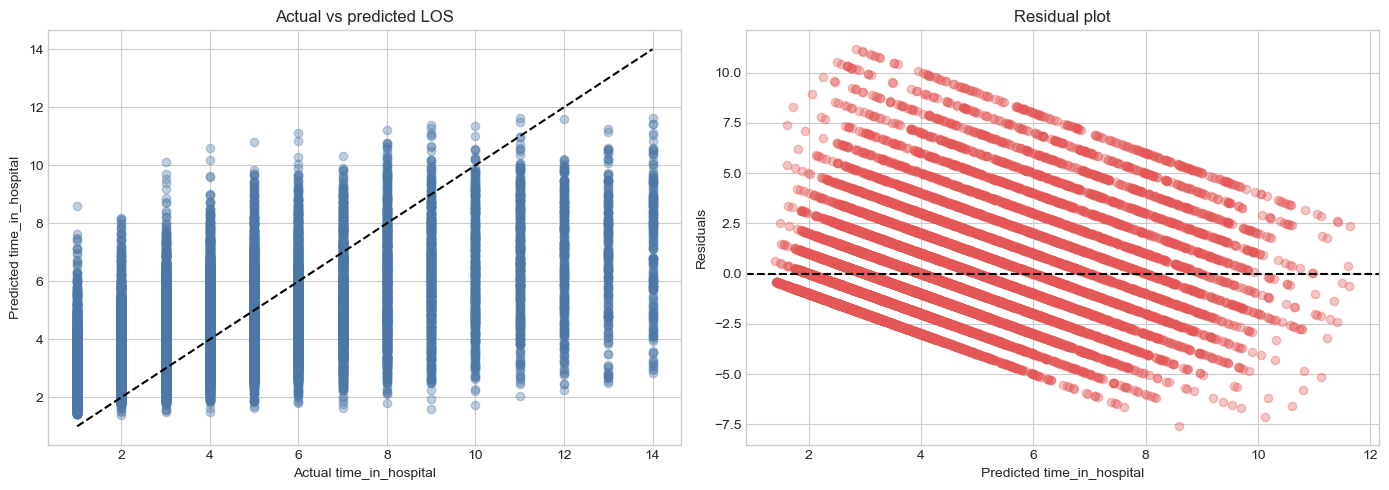

In [8]:
best_predictions = best_model.predict(X_test)
best_metrics = regression_metrics(y_test, best_predictions)
residuals = y_test - best_predictions

summary_df = pd.DataFrame([
    {
        'best_model': best_model_name,
        'MAE': best_metrics['MAE'],
        'RMSE': best_metrics['RMSE'],
        'R2': best_metrics['R2'],
    }
])
display(summary_df.style.format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_predictions, alpha=0.35, color='#4C78A8')
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black')
axes[0].set_title('Actual vs predicted LOS')
axes[0].set_xlabel('Actual time_in_hospital')
axes[0].set_ylabel('Predicted time_in_hospital')

axes[1].scatter(best_predictions, residuals, alpha=0.35, color='#E45756')
axes[1].axhline(0, linestyle='--', color='black')
axes[1].set_title('Residual plot')
axes[1].set_xlabel('Predicted time_in_hospital')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()


The **actual vs predicted** chart shows how closely model predictions align with the observed hospital stay. Points that sit near the diagonal line represent stronger prediction accuracy, while points farther away reflect larger errors. Points below the diagonal indicate underprediction, meaning the actual stay was longer than expected; points above the line indicate overprediction. Long-stay cases may be harder to predict because they can reflect more complex discharge barriers, complications, or care coordination needs that are not fully captured in structured fields.

The **residual plot** shows the gap between actual and predicted LOS for each encounter. Residuals centered around zero suggest a more balanced fit, while visible skew or widening spread can indicate bias or inconsistent performance across different types of stays. For hospital operations, this matters because systematic underprediction or overprediction can affect trust in LOS estimates used for capacity planning and discharge prioritization.

# Feature importance / interpretation

In [9]:
interpretable_output = None

if isinstance(best_model, Pipeline) and 'preprocessor' in best_model.named_steps:
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    fitted_estimator = best_model.named_steps['model']

    if hasattr(fitted_estimator, 'feature_importances_'):
        interpretable_output = (
            pd.DataFrame({
                'feature': feature_names,
                'importance': fitted_estimator.feature_importances_,
            })
            .sort_values('importance', ascending=False)
            .head(15)
            .reset_index(drop=True)
        )
        display(interpretable_output)
    elif hasattr(fitted_estimator, 'coef_'):
        interpretable_output = (
            pd.DataFrame({
                'feature': feature_names,
                'coefficient': fitted_estimator.coef_,
                'abs_coefficient': np.abs(fitted_estimator.coef_),
            })
            .sort_values('abs_coefficient', ascending=False)
            .head(15)
            .drop(columns='abs_coefficient')
            .reset_index(drop=True)
        )
        display(interpretable_output)
    else:
        print('The best model does not expose feature importances or linear coefficients.')
else:
    print('The baseline model does not provide transformed feature interpretation.')


,feature,importance
0,numeric__num_medications,0.482186
1,numeric__num_lab_procedures,0.174020
2,categorical__discharge_disposition_id_1,0.112135
3,numeric__num_procedures,0.044891
4,categorical__admission_source_id_4,0.017099
5,categorical__admission_type_id_3,0.016013
6,numeric__number_inpatient,0.013693
7,categorical__discharge_disposition_id_2,0.010068
8,categorical__admission_type_id_2,0.009118
9,numeric__number_outpatient,0.007083


This interpretation output shows which variables the selected model relied on most heavily, either through feature importance values or linear coefficients. Features near the top may suggest stronger association with LOS patterns in this dataset, such as utilization intensity, prior inpatient activity, or admission and discharge pathway variables.

These results are helpful for understanding model behavior and identifying which structured features appear most influential, but they should not be interpreted as causal. A feature can rank highly because it helps separate patterns in the data, not because it independently causes a longer or shorter hospital stay.

# Prediction examples

In [10]:
sample_predictions = X_test.head(10).copy()
sample_predictions['actual_time_in_hospital'] = y_test.head(10).values
sample_predictions['predicted_time_in_hospital'] = best_model.predict(X_test.head(10))
sample_predictions['absolute_error'] = (
    sample_predictions['actual_time_in_hospital'] - sample_predictions['predicted_time_in_hospital']
).abs()

display(sample_predictions)


,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,max_glu_serum,A1Cresult,insulin,change,diabetesMed,actual_time_in_hospital,predicted_time_in_hospital,absolute_error
35956,68,0,20,0,0,0,Caucasian,Female,[70-80),1,1,6,NaN,NaN,Steady,No,Yes,11.0,5.171244,5.828756
60927,20,0,7,0,0,0,Caucasian,Male,[50-60),1,1,1,NaN,NaN,No,No,Yes,1.0,2.125027,1.125027
79920,21,3,23,1,0,2,Caucasian,Female,[60-70),3,6,1,NaN,NaN,No,No,Yes,4.0,4.008711,0.008711
50078,28,0,19,0,0,1,Caucasian,Male,[30-40),2,1,1,NaN,NaN,No,No,Yes,12.0,4.755412,7.244588
44080,21,0,6,0,0,0,AfricanAmerican,Female,[60-70),1,2,7,NaN,NaN,No,No,Yes,1.0,1.630503,0.630503
4727,42,2,27,0,0,0,Caucasian,Male,[80-90),3,1,1,NaN,NaN,No,Ch,Yes,7.0,4.763323,2.236677
29944,43,2,17,0,0,0,AfricanAmerican,Female,[70-80),1,1,7,NaN,NaN,No,No,Yes,6.0,3.755803,2.244197
84575,55,0,20,1,1,0,Caucasian,Female,[40-50),1,6,7,NaN,>8,Up,Ch,Yes,5.0,5.573662,0.573662
59479,50,0,26,0,0,0,Caucasian,Male,[80-90),1,3,7,NaN,NaN,Up,Ch,Yes,5.0,6.556737,1.556737
56742,61,0,6,0,0,1,AfricanAmerican,Female,[60-70),1,6,7,NaN,Norm,No,No,No,7.0,3.483721,3.516279


# Limitations

This notebook uses a practical first-pass feature set and does not attempt full clinical feature engineering. The source data reflects an older timeframe, so observed patterns may not fully match current hospital workflows, treatment standards, or documentation practices.

The dataset is also centered on a diabetes-related encounter population, which means the results may not generalize directly to broader inpatient populations without additional validation. Important clinical nuance may be missing as well, including disease severity progression, social determinants, discharge readiness constraints, and other contextual factors that can influence length of stay.

Several inputs are coded administrative variables that require interpretation. These fields can be useful for prediction, but their practical meaning may vary and should be reviewed carefully before drawing conclusions. For that reason, model outputs should support operational judgment rather than replace it. LOS predictions may help with planning and prioritization, but they should be interpreted alongside clinical and organizational context.

# Potential Findings & Practical Takeaways

Likely findings from this notebook include:

- Length of stay appears to be associated with a combination of utilization intensity, prior inpatient use, and admission or discharge pathway features rather than a single dominant signal.
- Variables related to treatment complexity, such as medication and laboratory activity, may help distinguish encounters associated with longer stays.
- Admission and discharge process fields appear informative because they may reflect differences in acuity, care pathway complexity, or post-acute planning needs.
- Prediction quality is directionally useful, but longer-stay encounters may remain more difficult to estimate because they often involve factors that are only partially visible in structured data.

Operational takeaways for hospitals may include:

- Use LOS predictions as an early operational signal for capacity planning, discharge coordination, and case management review rather than as a fixed forecast.
- Focus follow-up attention on encounter groups where prediction errors remain larger, since those patterns may indicate missing workflow context or patient complexity not yet captured in the model.
- Combine model outputs with local process knowledge to identify where earlier intervention may help reduce avoidable delays.
